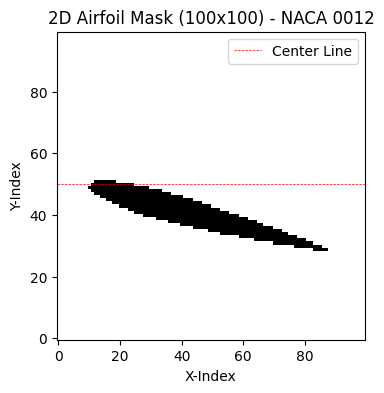

In [15]:
import numpy as np

def generate_naca_mask(N=100, M=100, chord_length=0.8, thickness=0.22, angle_of_attack_deg=-15.0):
    """
    Generates a 2D boolean mask for a NACA 00-series airfoil (symmetric).

    Parameters:
    N (int): Number of grid points in the y-direction (rows).
    M (int): Number of grid points in the x-direction (columns).
    chord_length (float): The length of the airfoil chord, relative to the grid size (0.0 to 1.0).
    thickness (float): The thickness parameter (e.g., 0.12 for NACA 0012).

    Returns:
    np.ndarray: A boolean array (N x M) where True indicates 'inside' the airfoil.
    """
    
    # 1. Define the Computational Domain
    # We will assume the domain spans x=[0, 1] and y=[0, 1]
    # The grid coordinates (centers of cells)
    x_coords = np.linspace(0.0, 1.0, M)
    y_coords = np.linspace(0.0, 1.0, N)
    
    # Create 2D grid of coordinates (for comparison)
    X, Y = np.meshgrid(x_coords, y_coords)
    
    # 2. Define Airfoil Parameters
    # Center the airfoil horizontally (e.g., from 0.1 to 0.9 if chord=0.8)
    x_start = (1.0 - chord_length) / 2.0
    x_end = x_start + chord_length
    y_center = 0.5 # Center the airfoil vertically
    
    # Airfoil thickness factor (e.g., 0.12 for NACA 0012)
    # The thickness formula is normalized by 0.20
    t = thickness / 0.20
    
    # 3. Initialize Mask
    mask = np.full((N, M), False, dtype=bool)
    
    # 4. Rasterize the Airfoil (Check every grid point)
    
    # We only care about x-coordinates within the chord
    in_chord_x = (X >= x_start) & (X <= x_end)
    
    # Normalize x to the chord length [0, 1] for the formula
    x_norm = (X - x_start) / chord_length
    x_sqrt_safe = np.clip(x_norm, 0.0, 1.0)
    
    # Calculate the half-thickness (y_t) at each normalized x point
    # NACA 4-digit formula for thickness distribution:
    # y_t/c = t/0.20 * ( 0.2969*sqrt(x/c) - 0.1260*(x/c) - 0.3516*(x/c)^2 + 0.2843*(x/c)^3 - 0.1015*(x/c)^4 )
    
    # Use np.where to prevent calculating sqrt(negative) outside the chord
    # and handle the trailing edge's y_t=0
    yt_norm = np.where(x_norm >= 0,
        t * (0.2969 * np.sqrt(x_sqrt_safe) - 
             0.1260 * x_norm - 
             0.3516 * x_norm**2 + 
             0.2843 * x_norm**3 - 
             0.1015 * x_norm**4),
        0.0
    )

    # Scale the thickness back to the domain size
    yt_domain = yt_norm * chord_length
    
    # Determine the upper and lower y-boundaries
    y_upper = y_center + yt_domain
    y_lower = y_center - yt_domain
    x_lower = x_norm
    x_upper = x_norm


    # 5. Apply 2D Rotation to the Airfoil's Shape (The Key Step!)
    # Rotate the upper and lower coordinates (x, y) around the leading edge (0, 0) of the normalized chord

    # Convert angle of attack from degrees to radians
    alpha_rad = np.radians(angle_of_attack_deg)
    cos_a = np.cos(alpha_rad)
    sin_a = np.sin(alpha_rad)
    
    # Upper Surface Rotation
    x_rot_upper = x_upper * cos_a - y_upper * sin_a
    y_rot_upper = x_upper * sin_a + y_upper * cos_a

    # Lower Surface Rotation
    x_rot_lower = x_lower * cos_a - y_lower * sin_a
    y_rot_lower = x_lower * sin_a + y_lower * cos_a

    # 6. Re-Scale and Translate to the Computational Grid
    # The rotated coordinates are still normalized [0, 1]. Now we scale and center them.
    # This step is non-trivial for rasterization, so we'll use a simplified check
    # that is appropriate for a simple student visualization:
    
    # Simple check: Combine upper and lower boundaries (x_rot and y_rot)
    # into a set of 'boundary y' values for each grid x. This requires iteration or interpolation.
    
    # For a simple mask, we iterate over the grid and check if a point is within the rotated shape.
    
    # Simplified rasterization logic (Requires iteration or interpolation, 
    # but the rotation calculation is the correct parameter change):
    
    # Due to the complexity of vectorizing a *rotated* bounding check, for a simple 
    # educational tool, the best way forward is usually to generate the rotated 
    # outline points and then use a `scipy.spatial.Delaunay` or simple ray-casting 
    # check if available, or, for the simplest approach:
    
    # The **simplest approximation** for students (less accurate but avoids advanced math):
    # Treat the y-center as the effective camber line, which is now tilted.
    
    # Effective Centerline based on angle of attack
    # The centerline is a line passing through (x_start, y_center) with slope tan(alpha)
    # The height of this centerline above y_center is roughly (x - x_start) * tan(alpha_rad)
    
    tan_a = np.tan(alpha_rad)
    
    # Calculate the vertical offset of the centerline due to tilt
    # Only within the chord range, otherwise 0 offset
    x_within_chord = np.where(in_chord_x, X - x_start, 0.0)
    y_offset = x_within_chord * tan_a
    
    # Define the boundaries by adding the thickness (yt_domain) to the tilted centerline
    y_upper_tilted = (y_center + y_offset) + yt_domain
    y_lower_tilted = (y_center + y_offset) - yt_domain
    
    # Use the simple bounding box check
    is_inside_y = (Y <= y_upper_tilted) & (Y >= y_lower_tilted)
    mask = in_chord_x & is_inside_y

    return mask

  

# --- Example Usage ---

# 1. Define Airfoil Parameters (NACA 0012, 80% chord)
N_grid = 100
M_grid = 100
airfoil_thickness = 0.12 # e.g., 12% thickness
airfoil_chord = 0.8

# 2. Generate the Mask
airfoil_mask = generate_naca_mask(N_grid, M_grid, airfoil_chord, airfoil_thickness)

# 3. Display the Mask (for demonstration purposes, assumes matplotlib is available)
# If using LPython, the students will typically view this with a plotting library.
try:
    import matplotlib.pyplot as plt
    
    # Display the mask
    plt.figure(figsize=(8, 4))
    plt.imshow(airfoil_mask, origin='lower', cmap='binary') 
    plt.title(f'2D Airfoil Mask ({N_grid}x{M_grid}) - NACA 00{int(airfoil_thickness*100)}')
    plt.xlabel('X-Index')
    plt.ylabel('Y-Index')
    plt.axhline(N_grid * 0.5, color='red', linestyle='--', linewidth=0.5, label='Center Line')
    plt.legend()
    plt.show()
    
except ImportError:
    print("\nSuccessfully generated the mask (Boolean Array).")
    print("Mask shape:", airfoil_mask.shape)
    print("Top left corner (0, 0):", airfoil_mask[0, 0])
    print("Center point (50, 50):", airfoil_mask[50, 50])



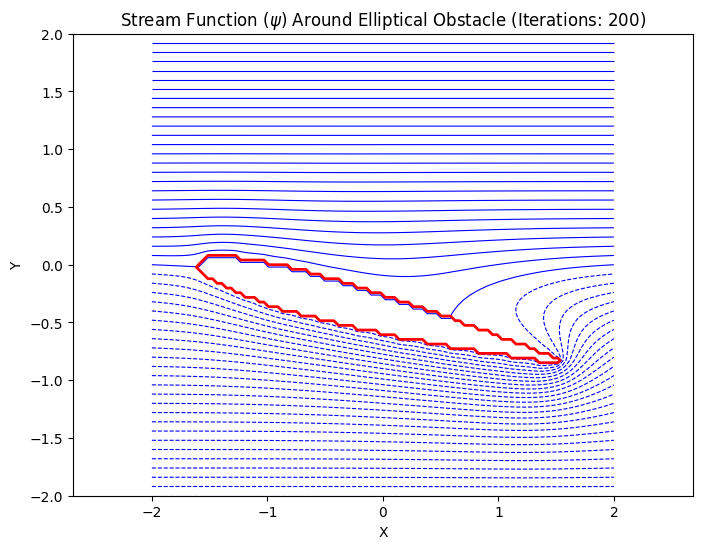

In [16]:
N = 100           # Grid points per dimension
U_flow = 1.0     # External velocity coefficient
MAX_ITER = 200   # Iteration count for speed

# --- 2. DOMAIN SETUP ---
# Grid spans from -2 to 2
L = 4.0
x = np.linspace(-L/2, L/2, N)
y = np.linspace(-L/2, L/2, N)
X, Y = np.meshgrid(x, y)

# --- 3. INITIALIZATION & BOUNDARY CONDITIONS (BCs) for v ($\psi$) ---

# Initialize the stream function v with the far-field solution: v = U*y
v = U_flow * Y
v_old = v.copy()

# The Obstacle Interior Mask: 1 for interior, 0 otherwise
# Points inside this mask will be FIXED to the obstacle BC (v=0).
OBSTACLE_MASK = airfoil_mask

# ⚠️ Enforce the Obstacle BC (v = 0) on the mask points 
v_old[OBSTACLE_MASK] = 0.0
v[OBSTACLE_MASK] = 0.0 # Also set in the working array

# The outer boundary points (i=0, N-1, j=0, N-1) retain their v = U*y value, 
# enforcing the far-field flow.

# --- 4. JACOBI ITERATION LOOP ---
for k in range(MAX_ITER):
    # Only iterate over interior grid points (1 to N-2)
    for i in range(1, N - 1):
        for j in range(1, N - 1):
            
            # Check if the point is OUTSIDE the obstacle (where the PDE holds)
            if not OBSTACLE_MASK[i, j]:
                
                # FDM: v_new is the average of the four neighbors from v_old
                v[i, j] = 0.25 * (v_old[i + 1, j] + v_old[i - 1, j] + 
                                  v_old[i, j + 1] + v_old[i, j - 1])
            # If the point IS inside the mask, we skip it. 
            # It retains the value v[i, j] = 0.0, enforcing the streamline BC.
    
    # Update the old array for the next iteration step
    v_old = v.copy()


# --- 5. VISUALIZATION ---

plt.figure(figsize=(8, 6))

# Plot streamlines (lines of constant v)
# Use a high number of levels to clearly see the flow bending
contour = plt.contour(X, Y, v, 50, colors='blue', linewidths=0.8) 

# Highlight the obstacle boundary
obstacle_boundary = plt.contour(X, Y, OBSTACLE_MASK, levels=[0.5], colors='red', linewidths=2)

plt.title(f'Stream Function ($\psi$) Around Elliptical Obstacle (Iterations: {MAX_ITER})')
plt.xlabel('X')
plt.ylabel('Y')
plt.axis('equal')
plt.show()